In [4]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d

import os
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('..')
sys.path.append('GP_regr')
import plot_settings
import importlib
#import multi_exp_log
import SR_lib

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

# Importing data

In [ ]:
RUN_ID = 'test'
SAVE  = True
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(2e1)

# check if run_id exists, if not create it
if os.path.exists(f'saved_sr_models/{RUN_ID}/model_UE_{RUN_ID}.csv'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')

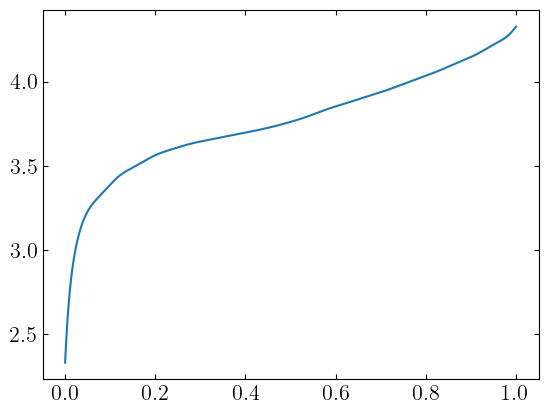

In [6]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)

In [7]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id Ueq_test4...
Settings: iterations=20, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.096151374
Equation: 3.76195

Model 1: Complexity=3, Loss=0.010166876
Equation: soc + 3.2619393

Model 2: Complexity=4, Loss=0.00942729
Equation: sqrt(soc) + 3.0944488

Model 3: Complexity=6, Loss=0.0050678374
Equation: (sqrt(soc) + 2.25192) * 1.2892156

Model 4: Complexity=7, Loss=0.0040565846
Equation: sqrt(sqrt(soc / 0.08196109)) + 2.2659314

Model 5: Complexity=8, Loss=0.004038816
Equation: ((soc ^ 0.2814739) * 1.7231985) + 2.4157076

Model 6: Complexity=9, Loss=0.0040132226
Equation: exp((soc ^ 0.12561393) - -0.29703528) - -0.47452497

Model 7: Complexity=10, Loss=0.0024275738
Equation: sqrt(sqrt(tan(soc) / 0.15461059)) + 2.4364347

Model 8: Complexity=11, Loss=0.0021777255
Equation: ((tan(soc) ^ 0.18389073) + 0.99731344) * 2.0175128

Model 9: Complexity=12, Loss=0.001956577
Equation: (sqrt(sqrt(soc * (soc ^ soc))) + 1.2110028) * 1.9153638

Model 10: Complexity=13, Loss=0.0016685749
Equation: exp((soc ^ 0.05944349) - -0.6024636) - cos(cube(soc))

Model

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(soc**0.17777051 - 1*(-0.5268365)) - sin(soc*1.479026) - cos(soc) - 1*(-1.22784)
Loss: 0.00034620002
Best model complexity: 21


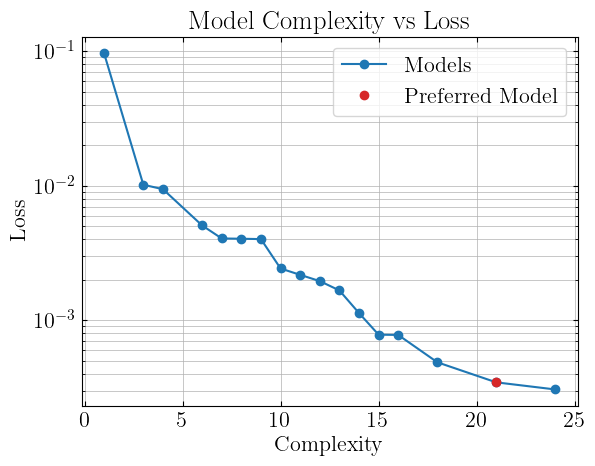

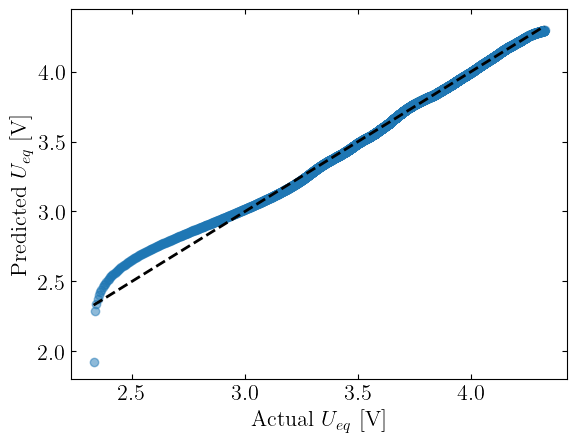

In [8]:
import_reload()
model_Ue = SR_lib.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ueq_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
SR_lib.print_models(df_model_Ue)
SR_lib.print_best_model(model_Ue)
SR_lib.pareto_plot(model_Ue)
SR_lib.parity_plot_Ue(model_Ue, Y_train, X_train, colors=colors, data_set='train')

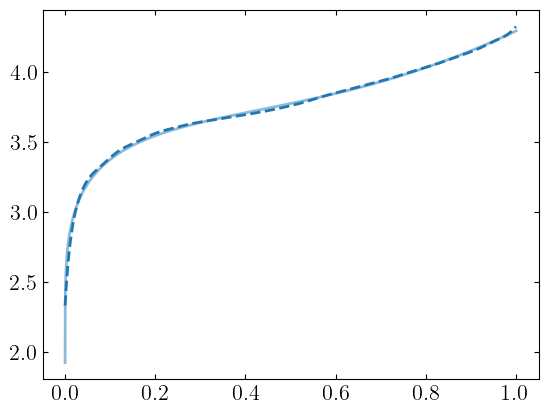

In [9]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [10]:
if SAVE:
    SR_lib.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}', run_id = RUN_ID)
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')